In [1]:
import torch
import matplotlib.pyplot as plt

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)


def true_controlled_vdp_dynamics(x, u, mu=1.0, b=1.0):
    """
    Controlled Van der Pol:

        dx1/dt = x2
        dx2/dt = mu*(1 - x1^2)*x2 - x1 + b*u

    x shape: [batch_size, 2]
    u shape: [batch_size, 1]
    """

    x1 = x[:, 0:1]
    x2 = x[:, 1:2]

    dx1dt = x2
    dx2dt = mu * (1.0 - x1**2) * x2 - x1 + b * u

    return torch.cat([dx1dt, dx2dt], dim=1)


def rk4_step_true_controlled_vdp(x, u, dt, mu=1.0, b=1.0):
    """
    RK4 step for the true controlled Van der Pol dynamics.
    """

    k1 = true_controlled_vdp_dynamics(x, u, mu, b)
    k2 = true_controlled_vdp_dynamics(x + 0.5 * dt * k1, u, mu, b)
    k3 = true_controlled_vdp_dynamics(x + 0.5 * dt * k2, u, mu, b)
    k4 = true_controlled_vdp_dynamics(x + dt * k3, u, mu, b)

    x_next = x + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

    return x_next

Using device: mps


In [2]:
def rollout_true_dynamics(x0, u_seq, dt, mu=1.0, b=1.0):
    """
    Rollout the true controlled Van der Pol dynamics given an initial state and a sequence of control inputs.

    x0 shape: [1, 2]
    u_seq shape: [Np, 1]

    return:
        states shape: [Np + 1, 2]
    """

    states = [x0.squeeze(0)]
    x = x0

    for k in range(u_seq.shape[0]):
        u_k = u_seq[k:k+1, :]   # shape [1, 1]

        x = rk4_step_true_controlled_vdp(
            x=x,
            u=u_k,
            dt=dt,
            mu=mu,
            b=b
        )

        states.append(x.squeeze(0))

    return torch.stack(states, dim=0)

In [3]:
Q  = [10, 1]
R  = 0.1
Qf = [30, 5]
b  = 1.0

In [4]:
def mpc_cost(states, u_seq, x_ref, u_ref, q, r, qf):
    """
    states shape: [Np + 1, 2]
    u_seq shape: [Np, 1]
    x_ref shape: [2]
    u_ref shape: [1]
    """

    # Tracking state error
    err = states[:-1] - x_ref
    state_cost = torch.sum(q * err**2)

    # Penalize input deviation from u_ref, not from 0
    input_err = u_seq - u_ref
    input_cost = r * torch.sum(input_err**2)

    # Terminal cost
    terminal_err = states[-1] - x_ref
    terminal_cost = torch.sum(qf * terminal_err**2)

    return state_cost + input_cost + terminal_cost

In [5]:
def solve_mpc_true(
    x_current,
    x_ref,
    u_ref,
    Np=20,
    dt=0.05,
    mu=1.0,
    b=1.0,
    u_max=3.0,
    num_iters=100,
    lr=0.05
):
    """
    Solve the MPC problem using gradient-based optimization on the true dynamics.
    x_current shape: [1, 2]
    x_ref shape: [2]

    return:
        u_opt: [Np, 1]
        states_opt: [Np + 1, 2]
        cost_history: list
    """

    q = torch.tensor([10.0, 1.0], device=device)
    qf = torch.tensor([30.0, 5.0], device=device)
    r = torch.tensor(0.1, device=device)

    # Initialize the control sequence 
    raw_u = torch.zeros(Np, 1, device=device, requires_grad=True)

    optimizer = torch.optim.Adam([raw_u], lr=lr)

    cost_history = []

    for _ in range(num_iters):
        optimizer.zero_grad()

        u_seq = u_max * torch.tanh(raw_u)

        states = rollout_true_dynamics(
            x0=x_current,
            u_seq=u_seq,
            dt=dt,
            mu=mu,
            b=b
        )

        cost = mpc_cost(
            states=states,
            u_seq=u_seq,
            x_ref=x_ref,
            u_ref=u_ref,
            q=q,
            r=r,
            qf=qf
        )

        cost.backward()
        optimizer.step()

        cost_history.append(cost.item())

    with torch.no_grad():
        u_opt = u_max * torch.tanh(raw_u)

        states_opt = rollout_true_dynamics(
            x0=x_current,
            u_seq=u_opt,
            dt=dt,
            mu=mu,
            b=b
        )

    return u_opt.detach(), states_opt.detach(), cost_history

In [6]:
# Test the MPC solver with example current state and reference
x_current = torch.tensor([[2.0, 0.0]], device=device)
x_ref = torch.tensor([0.0, 0.0], device=device)
u_ref = torch.tensor([0.0], device=device)

u_opt, states_pred, cost_history = solve_mpc_true(
    x_current=x_current,
    x_ref=x_ref,
    u_ref=u_ref,
    Np=20,
    dt=0.05,
    mu=1.0,
    b=1.0,
    u_max=3.0,
    num_iters=200,
    lr=0.05
)

print("u_opt shape:", u_opt.shape)
print("states_pred shape:", states_pred.shape)
print("first control u0:", u_opt[0].item())

u_opt shape: torch.Size([20, 1])
states_pred shape: torch.Size([21, 2])
first control u0: -2.966627597808838


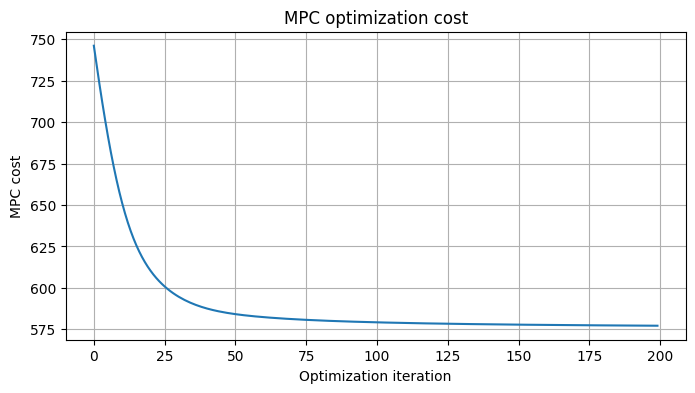

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(cost_history)
plt.xlabel("Optimization iteration")
plt.ylabel("MPC cost")
plt.title("MPC optimization cost")
plt.grid(True)
plt.show()

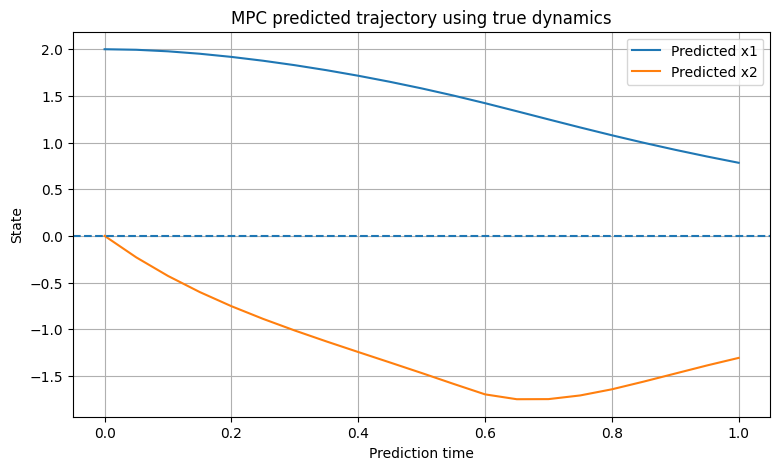

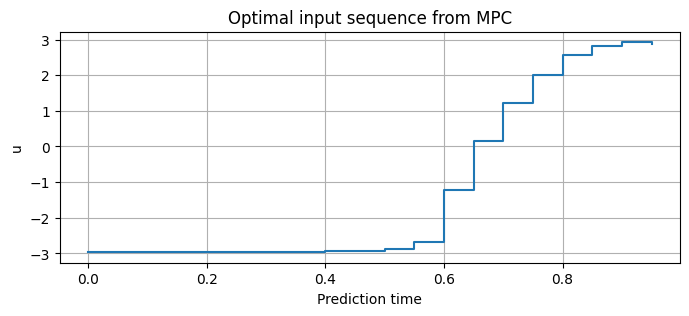

In [8]:
t_pred = torch.arange(states_pred.shape[0]) * 0.05

plt.figure(figsize=(9, 5))
plt.plot(t_pred.cpu().numpy(), states_pred[:, 0].cpu().numpy(), label="Predicted x1")
plt.plot(t_pred.cpu().numpy(), states_pred[:, 1].cpu().numpy(), label="Predicted x2")
plt.axhline(0.0, linestyle="--")
plt.xlabel("Prediction time")
plt.ylabel("State")
plt.title("MPC predicted trajectory using true dynamics")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 3))
plt.step(
    t_pred[:-1].cpu().numpy(),
    u_opt[:, 0].cpu().numpy(),
    where="post"
)
plt.xlabel("Prediction time")
plt.ylabel("u")
plt.title("Optimal input sequence from MPC")
plt.grid(True)
plt.show()

In [9]:
def simulate_closed_loop_mpc_true(
    x_init,
    x_ref,
    u_ref,
    sim_steps=100,
    Np=20,
    dt=0.05,
    mu=1.0,
    b=1.0,
    u_max=3.0,
    num_iters=80,
    lr=0.05
):
    """
    Closed-loop MPC simulation.
    """

    x = x_init.clone().to(device)

    x_history = [x.squeeze(0).detach().cpu()]
    u_history = []

    for step in range(sim_steps):
        u_opt, _, _ = solve_mpc_true(
            x_current=x,
            x_ref=x_ref,
            u_ref=u_ref,
            Np=Np,
            dt=dt,
            mu=mu,
            b=b,
            u_max=u_max,
            num_iters=num_iters,
            lr=lr
        )

        # Only apply the first control input
        u0 = u_opt[0:1, :]  # shape [1, 1]

        # Apply to the true system
        x = rk4_step_true_controlled_vdp(
            x=x,
            u=u0,
            dt=dt,
            mu=mu,
            b=b
        )

        x_history.append(x.squeeze(0).detach().cpu())
        u_history.append(u0.squeeze(0).detach().cpu())

        if step % 10 == 0:
            print(f"Step {step:3d} | x = {x.squeeze(0).detach().cpu().numpy()} | u = {u0.item():.4f}")

    x_history = torch.stack(x_history, dim=0)
    u_history = torch.stack(u_history, dim=0)

    return x_history, u_history

In [ ]:
x_init = torch.tensor([[2.0, 0.0]], device=device)
x_ref = torch.tensor([1.0, 0.0], device=device)
u_ref = torch.tensor([x_ref[0].item() / b], device=device)

x_hist, u_hist = simulate_closed_loop_mpc_true(
    x_init=x_init,
    x_ref=x_ref,
    u_ref=u_ref,
    sim_steps=100,
    Np=20,
    dt=0.05,
    mu=1.0,
    b=1.0,
    u_max=3.0,
    num_iters=80,
    lr=0.05
)

Step   0 | x = [ 1.9945703  -0.21187538] | u = -2.5640
Step  10 | x = [ 1.7359271 -0.5049972] | u = 1.2791
Step  20 | x = [ 1.5628048  -0.20398976] | u = 1.7399
Step  30 | x = [ 1.5063993  -0.04595188] | u = 1.6345
Step  40 | x = [1.4981123e+00 6.0702511e-04] | u = 1.5335
Step  50 | x = [1.5001256  0.00457641] | u = 1.5019
Step  60 | x = [1.501711   0.00178973] | u = 1.4992
Step  70 | x = [1.5021678e+00 3.0804443e-04] | u = 1.5010
Step  80 | x = [ 1.5022088e+00 -3.7300932e-05] | u = 1.5020
Step  90 | x = [ 1.5021842e+00 -4.2862044e-05] | u = 1.5022


In [11]:
dt = 0.05

x_ref_cpu = x_ref.detach().cpu()
u_ref_cpu = u_ref.detach().cpu()

t_sim = torch.arange(x_hist.shape[0]) * dt
t_u = torch.arange(u_hist.shape[0]) * dt

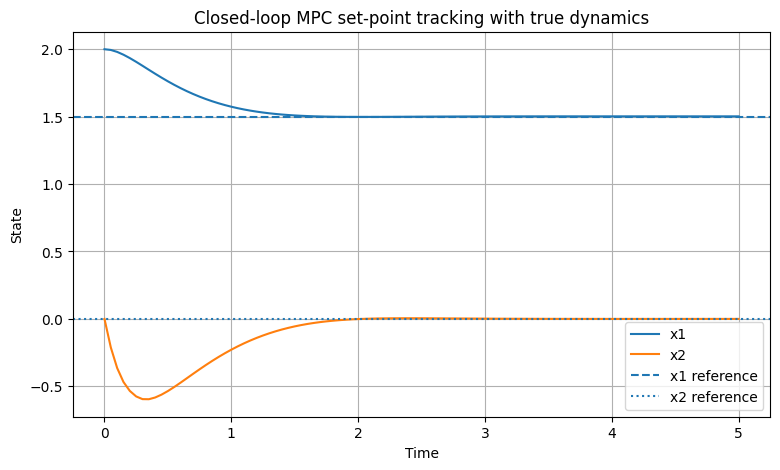

In [12]:
plt.figure(figsize=(9, 5))

plt.plot(t_sim.numpy(), x_hist[:, 0].numpy(), label="x1")
plt.plot(t_sim.numpy(), x_hist[:, 1].numpy(), label="x2")

# Reference lines
plt.axhline(x_ref_cpu[0].item(), linestyle="--", label="x1 reference")
plt.axhline(x_ref_cpu[1].item(), linestyle=":", label="x2 reference")

plt.xlabel("Time")
plt.ylabel("State")
plt.title("Closed-loop MPC set-point tracking with true dynamics")
plt.legend()
plt.grid(True)
plt.show()

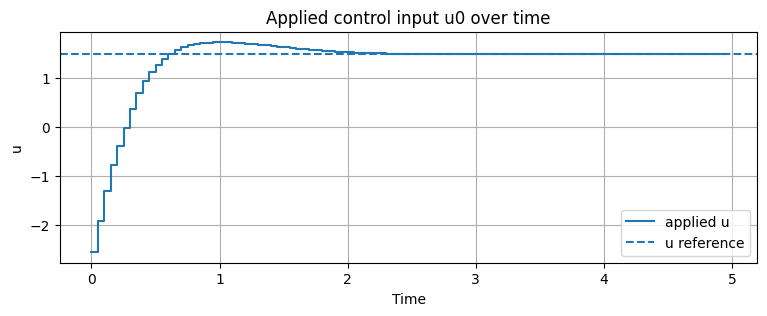

In [13]:
plt.figure(figsize=(9, 3))

plt.step(t_u.numpy(), u_hist[:, 0].numpy(), where="post", label="applied u")

# Reference input
plt.axhline(u_ref_cpu[0].item(), linestyle="--", label="u reference")

plt.xlabel("Time")
plt.ylabel("u")
plt.title("Applied control input u0 over time")
plt.legend()
plt.grid(True)
plt.show()
